In [37]:
# imports
import numpy as np
import pandas as pd

# plotting libraries
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold, cross_validate

# Classifiers
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error, RocCurveDisplay, PrecisionRecallDisplay
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, roc_curve, auc

import xgboost as xgb


# Pipeline
from sklearn.compose import ColumnTransformer 
from sklearn.preprocessing import RobustScaler

from sklearn.feature_selection import mutual_info_classif


In [38]:
df_train = pd.read_csv('..\\data\\train.csv')
y = df_train['IsFraud']
X = df_train.drop(['IsFraud', 'id', 'Time'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

model = xgb.XGBClassifier(tree_method='gpu_hist',
                        predictor='gpu_predictor',
                        gpu_id=0,
                        n_jobs=1,
                        subsample= 0.5, n_estimators = 400, min_child_weight = 5, max_depth = 3, learning_rate = 0.01, gamma = 0.2, colsample_bytree = 0.7)

preprocessor = ColumnTransformer([
    ("robust_scale", RobustScaler(), ['Transaction_Amount']),
], remainder='passthrough')

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

pipeline.fit(X_train,y_train)

c:\Users\tinew\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [09:10:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\tinew\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [09:10:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('robust_scale', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [40]:
preds = pipeline.predict(X_test)

## Use right metrics for imbalanced classification


In [41]:
# Detaiiled precision/recall/F1 by class:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     29947
           1       0.00      0.00      0.00        53

    accuracy                           1.00     30000
   macro avg       0.50      0.50      0.50     30000
weighted avg       1.00      1.00      1.00     30000



c:\Users\tinew\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\tinew\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\tinew\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [ ]:
# 2) ROC AUC for overall separability
probs = model.predict_proba(X_test)[:,1]
print('ROC AUC:', roc_auc_score(y_test, probs))

# 3) Precision-Recall AUC (more informative when positives are rare):
precision, recall, _ = precision_recall_curve(y_test, probs)
print('PR AUC', auc(recall, precision))

ROC AUC: 0.5312479720462124
PR AUC 0.0021692443800982964


<function matplotlib.pyplot.show(close=None, block=None)>

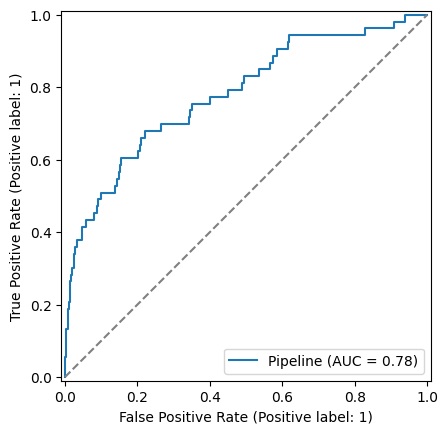

In [44]:
disp = RocCurveDisplay.from_estimator(
    pipeline, X_test, y_test,
    # name=f'ROC (AUC = {roc_auc:.3f})'
)
plt.plot([0,1],[0,1],'--',color='gray')
plt.show

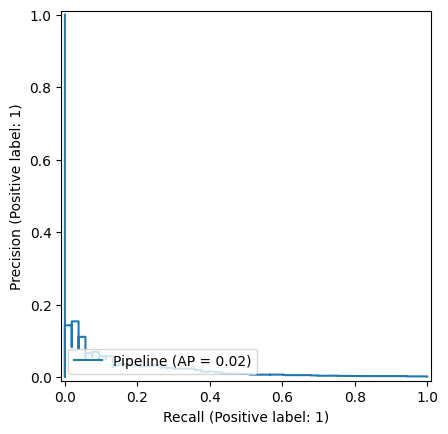

In [45]:
disp2 = PrecisionRecallDisplay.from_estimator(
    pipeline, X_test, y_test,
)
plt.show()

# Submission for Kaggle

We use our model to make predictions based on the test data from the Kaggle competition Credit Card Fraud Detection (the link: https://www.kaggle.com/competitions/credit-card-fraud-prediction/)


In [48]:
test_df = pd.read_csv('../data/test.csv')
submission_data = test_df.drop(['id','Time'], axis=1)
preds_for_submission = model.predict_proba(submission_data) # Get predictions

output = pd.DataFrame(
    {
        'id' : test_df.id,
        'IsFraud' : preds_for_submission[:,1]
    }
)
output.to_csv('submission.csv', index=False)
output.head()

,id,IsFraud
0,150000,0.006404
1,150001,0.002519
2,150002,0.009055
3,150003,0.001939
4,150004,0.002548


Firstly, we got 0.68747 for the Private Score and 0.77137 for the Public Score.

Then, we dropped Time feature and got improved results: 0.70195 Private Score and 0.77137 for the Public Score.

![image.png](attachment:image.png)
